In [51]:
library(tidyverse) # dplyr and ggplot2; CRAN
library(Seurat) # Seurat toolkit; CRAN
library(hdf5r) # for data import; CRAN
library(patchwork) # for plotting; CRAN 
library(presto) # for differential expression; Github
library(glmGamPoi) # for sctransform; Bioconductor
library(ggplot2) # for visualization; installed with tidyverse
library(dplyr) #just to make sure it was called; installed with tidyverse


library(SingleR) # for cell type annotation; Bioconductor
library(celldex) # for cell type annotation reference; Bioconductor
library(MAST) # for differential expression; Bioconductor
library(HGNChelper)

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.



In [4]:
mem.maxVSize(vsize=212384)

[1] 212384

In [6]:
adp <- readRDS("./merged_Seurat_adp.rds")

In [7]:
glimpse(adp)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  ..@ meta.data   :'data.frame':	50429 obs. of  6 variables:
  .. ..$ orig.ident  : chr [1:50429] "D10" "D10" "D10" "D10" ...
  .. ..$ nCount_RNA  : num [1:50429] 11188 32832 28515 18954 27181 ...
  .. ..$ nFeature_RNA: int [1:50429] 3383 5823 5002 4305 4586 1030 5015 3927 4006 5489 ...
  .. ..$ condition   : chr [1:50429] "DKO" "DKO" "DKO" "DKO" ...
  .. ..$ time_point  : chr [1:50429] "Day 0" "Day 0" "Day 0" "Day 0" ...
  .. ..$ cond_tp     : chr [1:50429] "DKO Day 0" "DKO Day 0" "DKO Day 0" "DKO Day 0" ...
  ..@ active.assay: chr "RNA"
  ..@ active.ident: Factor w/ 8 levels "D10","D16","D20",..: 1 1 1 1 1 1 1 1 1 1 ...
  .. ..- attr(*, "names")= chr [1:50429] "D10_AAACCCAAGATGCTTC-1" "D10_AAACCCAAGCTCTTCC-1" "D10_AAACCCAAGTCATCGT-1" "D10_AAACCCAGTAGCGTCC-1" ...
  ..@ graphs      : list()
  ..@ neighbors   : list()
  ..@ re

In [9]:
adp[["percent.mt"]] <- PercentageFeatureSet(adp, pattern = "^mt-")
metadata <- adp@meta.data

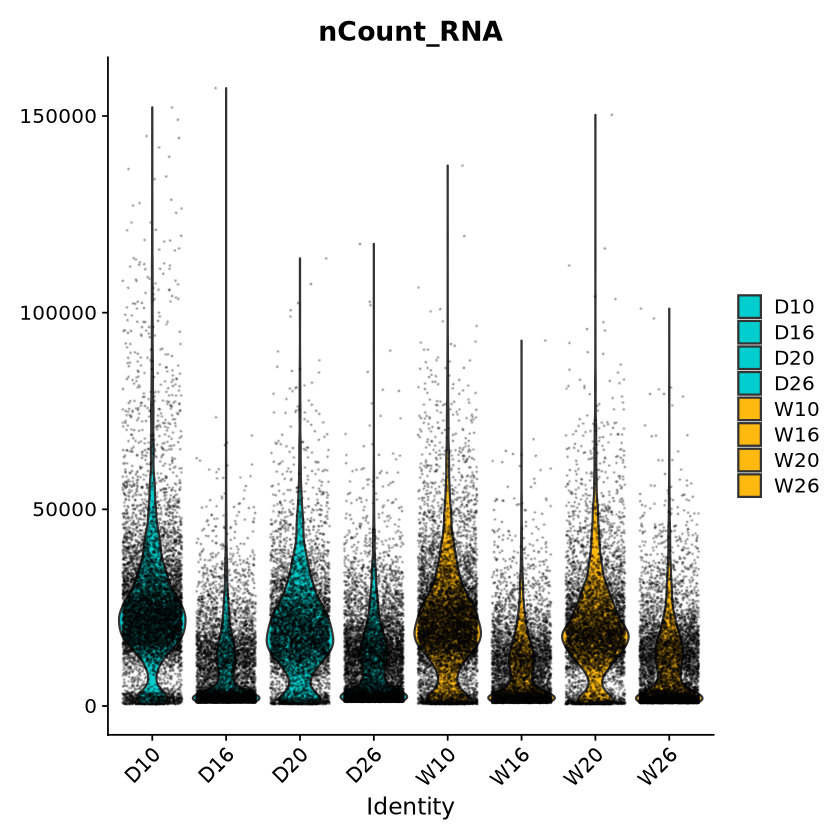

In [10]:
# set colors
cnames<-setNames(rep(c("cyan3","darkgoldenrod1"),each=4),levels(factor(metadata$orig.ident))) 

# plot
VlnPlot(adp, features = "nCount_RNA", layer="counts", group.by="orig.ident",raster=FALSE,alpha=0.2) +
  scale_fill_manual(values=cnames) 

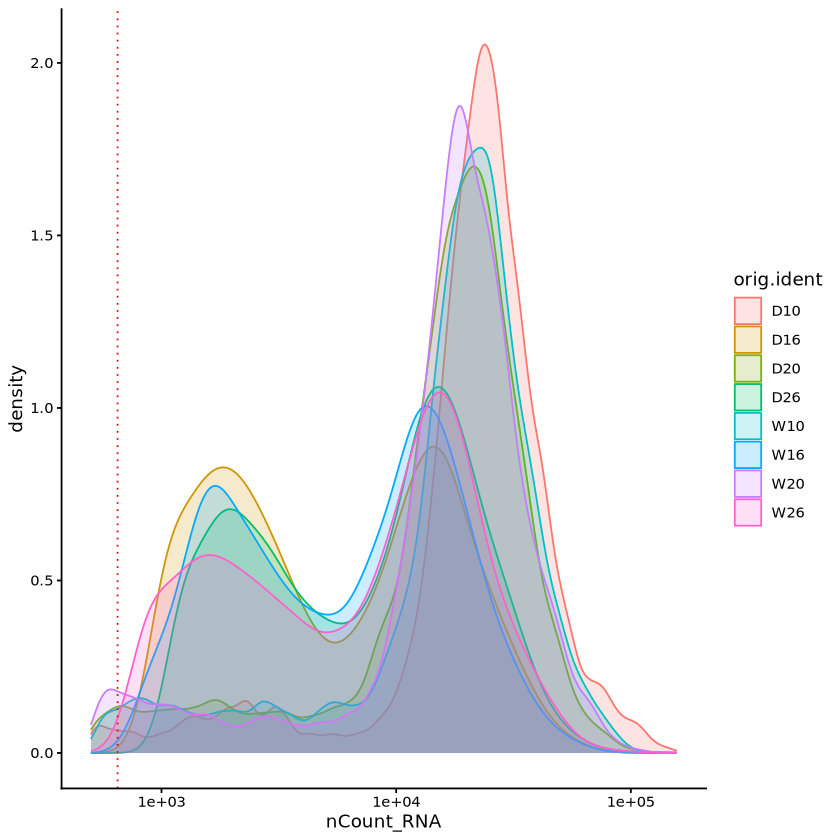

In [11]:
metadata %>% 
    ggplot(aes(color=orig.ident, x=nCount_RNA, fill= orig.ident)) + 
    geom_density(alpha = 0.2) + 
    theme_classic() +
    scale_x_log10() + 
    geom_vline(xintercept = 650,color="red",linetype="dotted")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


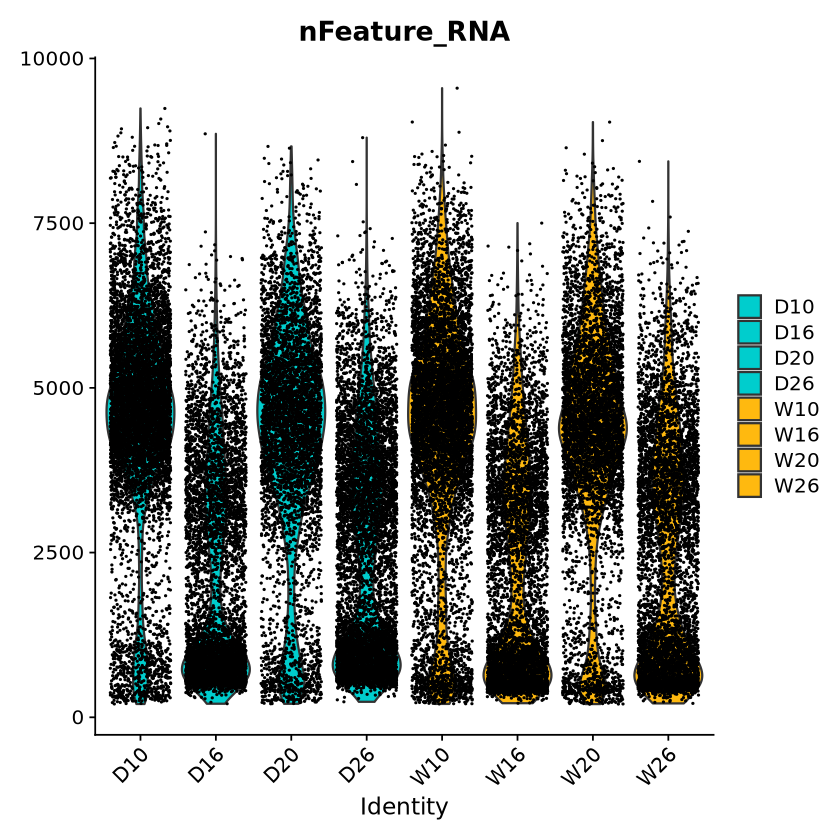

In [12]:
VlnPlot(adp, features = "nFeature_RNA", group.by="orig.ident") +
  scale_fill_manual(values=cnames) 

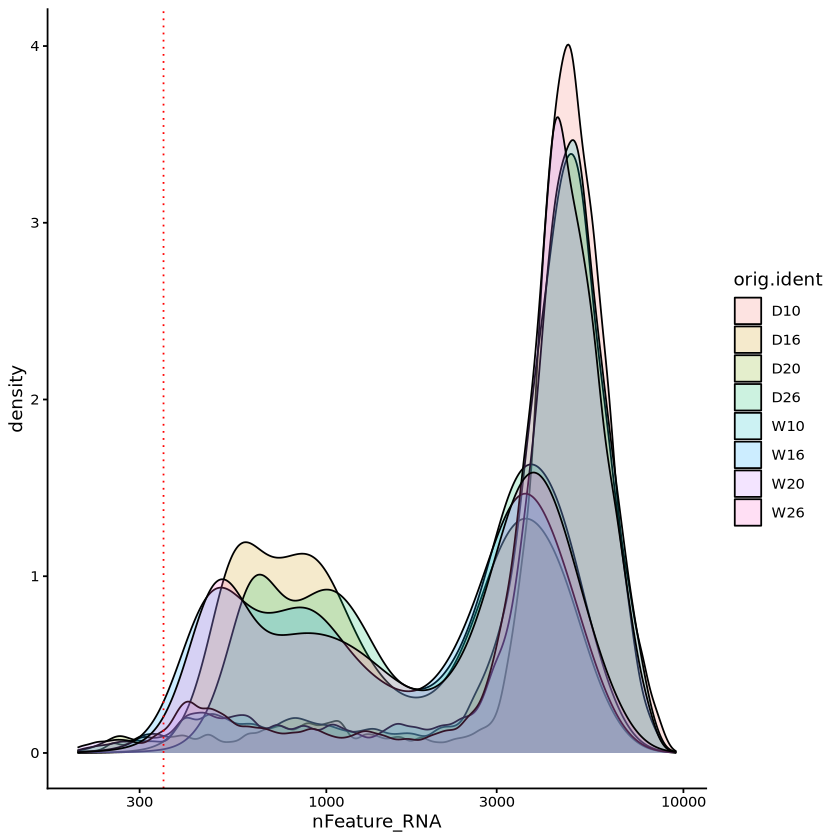

In [13]:
ggplot(metadata, aes(x=nFeature_RNA,fill=orig.ident)) +
   geom_density(alpha = 0.2) + 
    theme_classic() +
    scale_x_log10() + 
    geom_vline(xintercept = 350,color="red",linetype="dotted")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


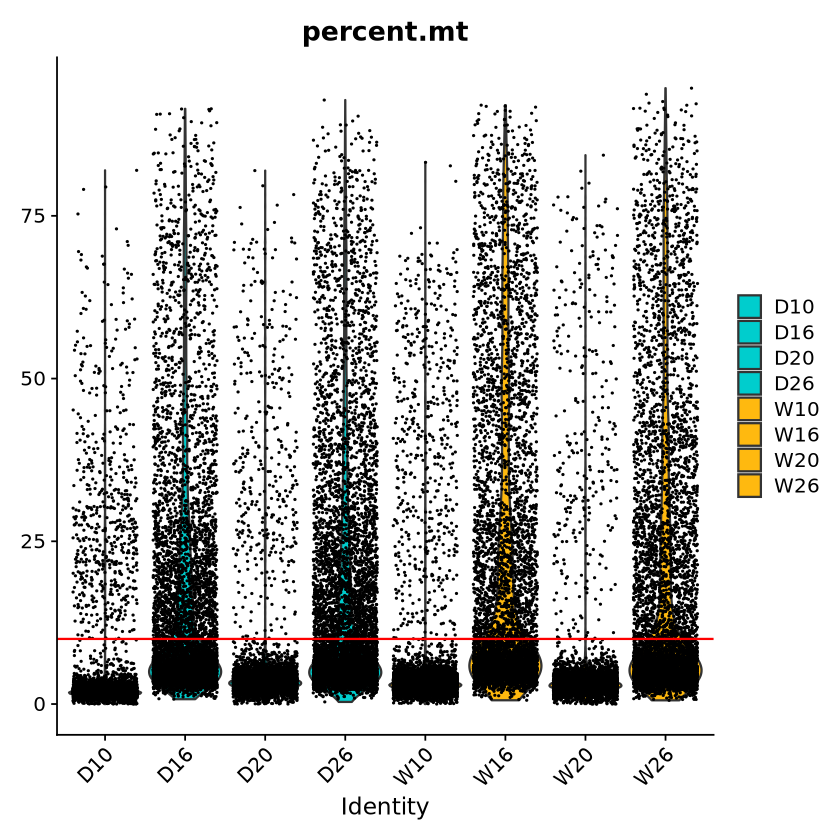

In [14]:
VlnPlot(adp, features = "percent.mt", group.by="orig.ident") +
  scale_fill_manual(values=cnames) +
  geom_hline(yintercept=10,color="red")

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 13 rows containing non-finite outside the scale range
(`stat_density()`).”


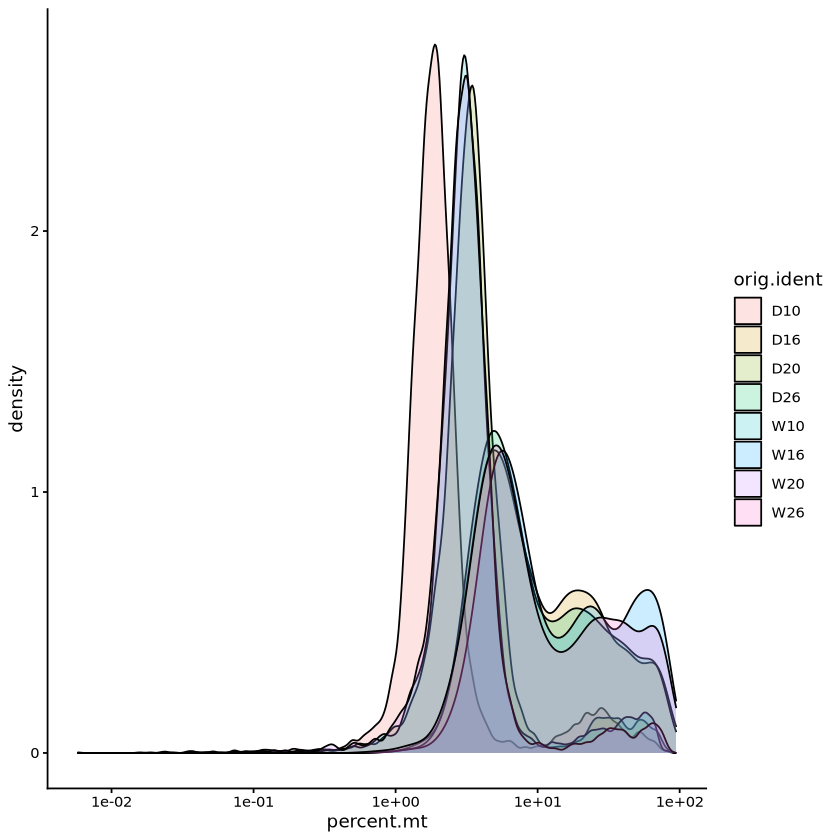

In [15]:
ggplot(metadata, aes(x=percent.mt,fill=orig.ident)) +
   geom_density(alpha = 0.2) + 
  scale_x_log10()+
    theme_classic()  

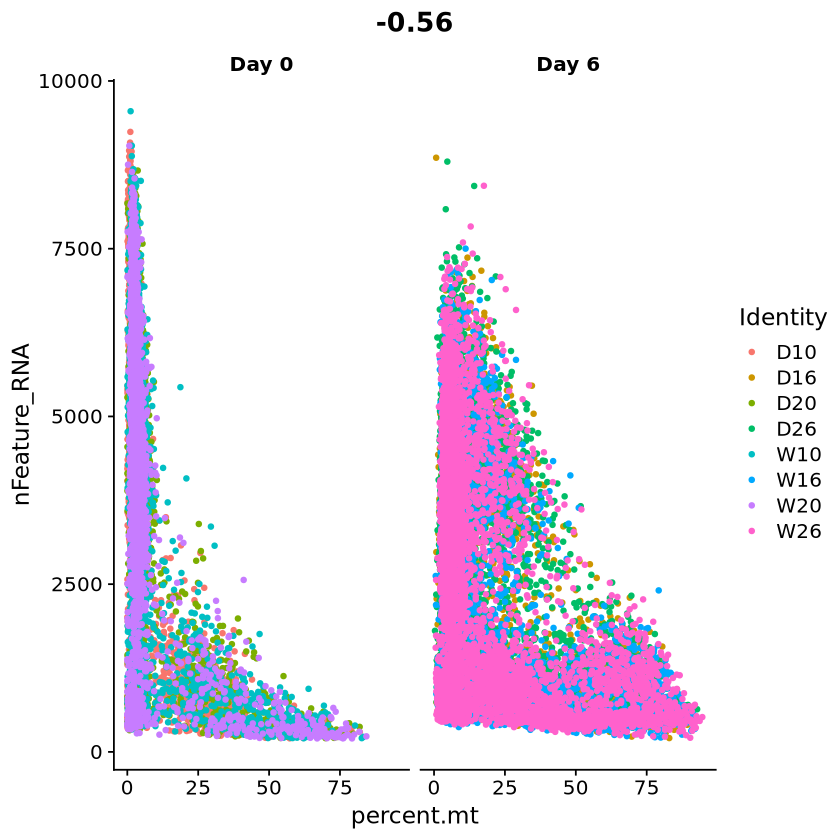

In [16]:
FeatureScatter(adp, feature1 = "percent.mt", feature2 ="nFeature_RNA" , group.by="orig.ident",split.by="time_point") 

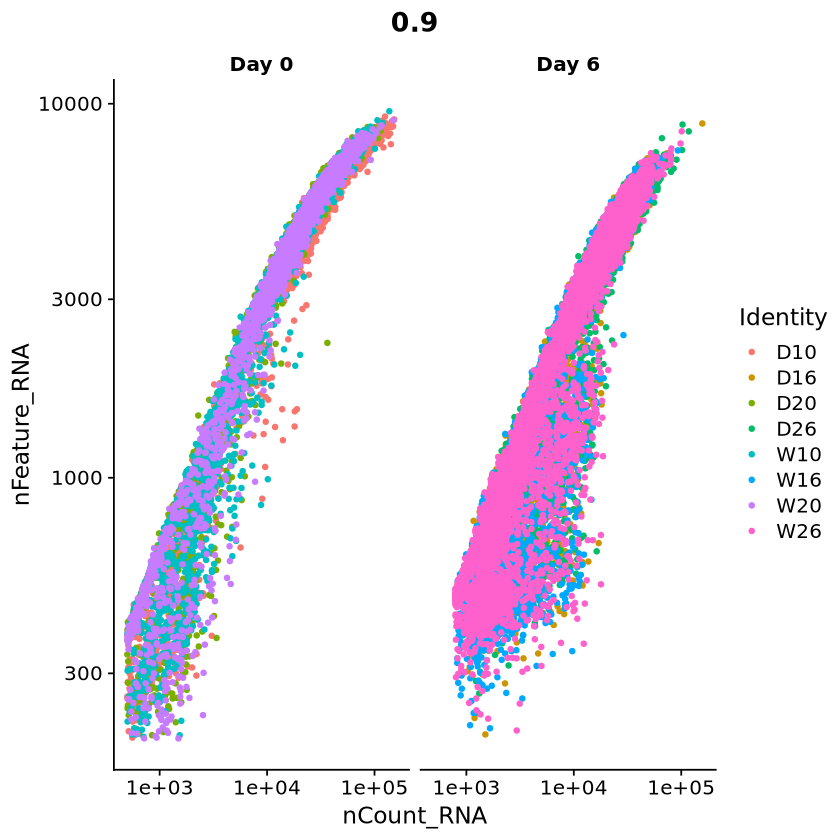

In [17]:
FeatureScatter(adp, feature1 = "nCount_RNA", feature2 = "nFeature_RNA",group.by="orig.ident",split.by="time_point",log=TRUE)

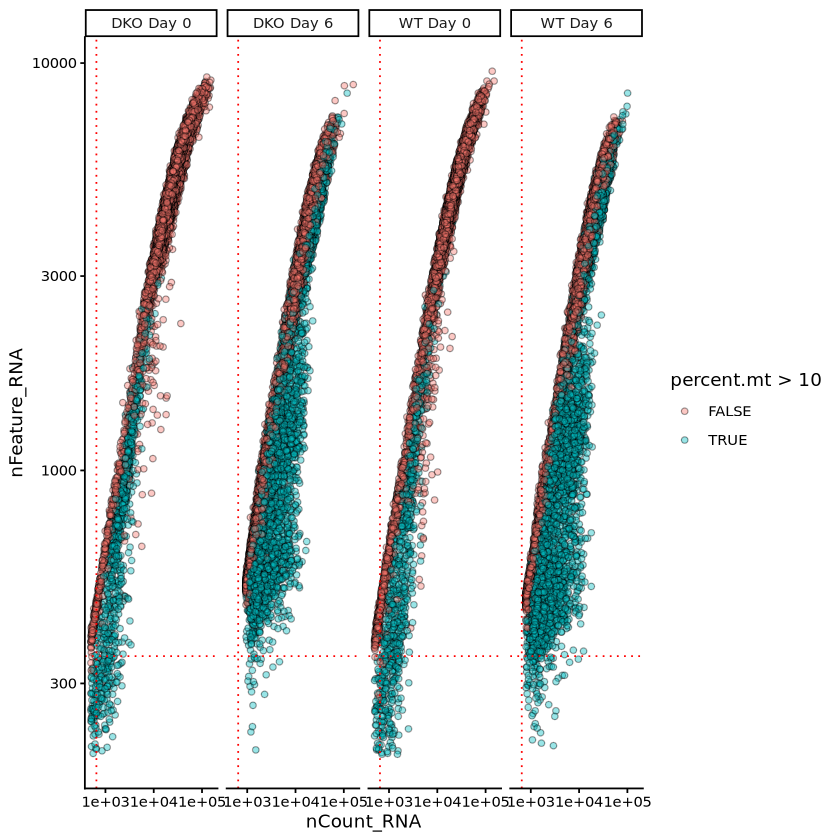

In [18]:
ggplot(metadata) +
  geom_point(aes(x=nCount_RNA,y=nFeature_RNA,fill=percent.mt > 10),shape=21,alpha=0.4) + 
  theme_classic() +
  scale_x_log10()+
  scale_y_log10()+
  facet_grid(.~cond_tp) +
  geom_vline(xintercept = 650,color="red",linetype="dotted")+
  geom_hline(yintercept=350,color="red", linetype="dotted")

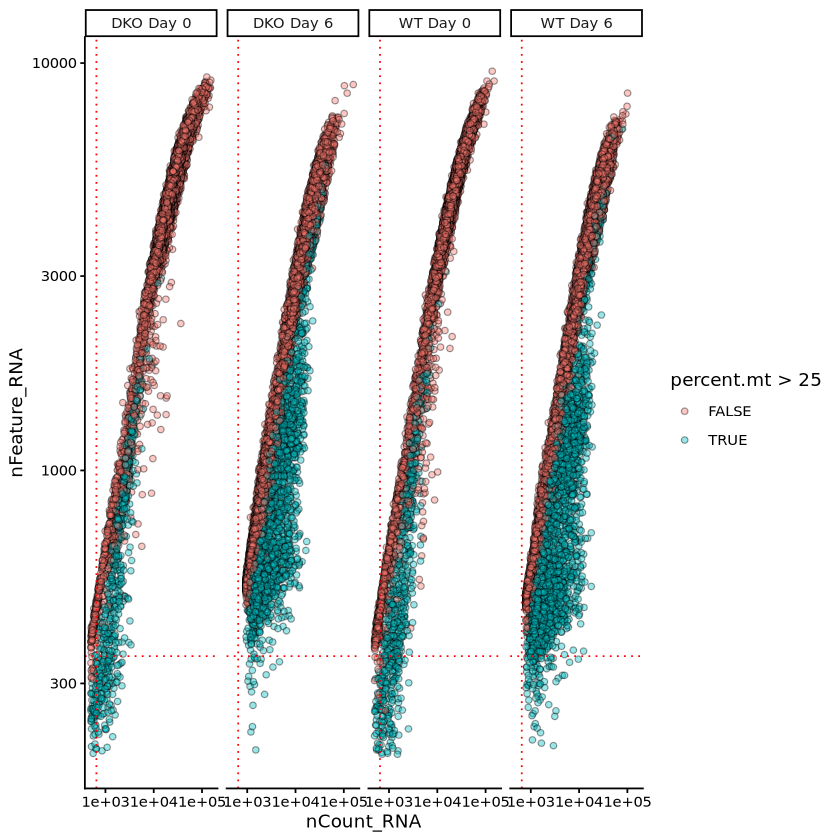

In [19]:
ggplot(metadata) +
  geom_point(aes(x=nCount_RNA,y=nFeature_RNA,fill=percent.mt > 25),shape=21,alpha=0.4) + 
  theme_classic() +
  scale_x_log10()+
  scale_y_log10()+
  facet_grid(.~cond_tp) +
  geom_vline(xintercept = 650,color="red",linetype="dotted")+
  geom_hline(yintercept=350,color="red", linetype="dotted")

In [20]:
# Set one set of parameters for Day 0 samples; 
# keep the rownames (Cell barcodes)
t0<- metadata |> filter(time_point=="Day 0", nFeature_RNA > 350, 
                        nCount_RNA >650, percent.mt <10 ) |> 
  rownames_to_column("Cell") |> pull(Cell) 

# Set an alternative set of thresholds for Day 6 samples; 
# keep the rownames (Cell barcodes)
t6<- metadata |> filter(time_point=="Day 6", nFeature_RNA > 350, 
                        nCount_RNA >650, percent.mt <25 ) |> 
  rownames_to_column("Cell") |> pull(Cell)

keep<-c(t0,t6)

In [21]:
# use different parameters; established above
adp_filt<-subset(adp, cells=keep)

In [24]:
saveRDS(adp_filt,"/Users/varunshamanna/Github_repos/SC-demo_notebooks/seurat_tutorials/QC/adp_merge_filt.rds")

In [22]:
# use multicore parallelism (Linux/SageMaker)
plan("multicore", workers = 22)

# increase memory limit for futures
options(future.globals.maxSize = 200 * 1024^3)  # 12 GB

In [23]:
adp_filt <- SCTransform(adp_filt, vars.to.regress = "percent.mt", verbose = FALSE)

In [24]:
adp_filt <- RunPCA(adp_filt, verbose = FALSE,assay="SCT")

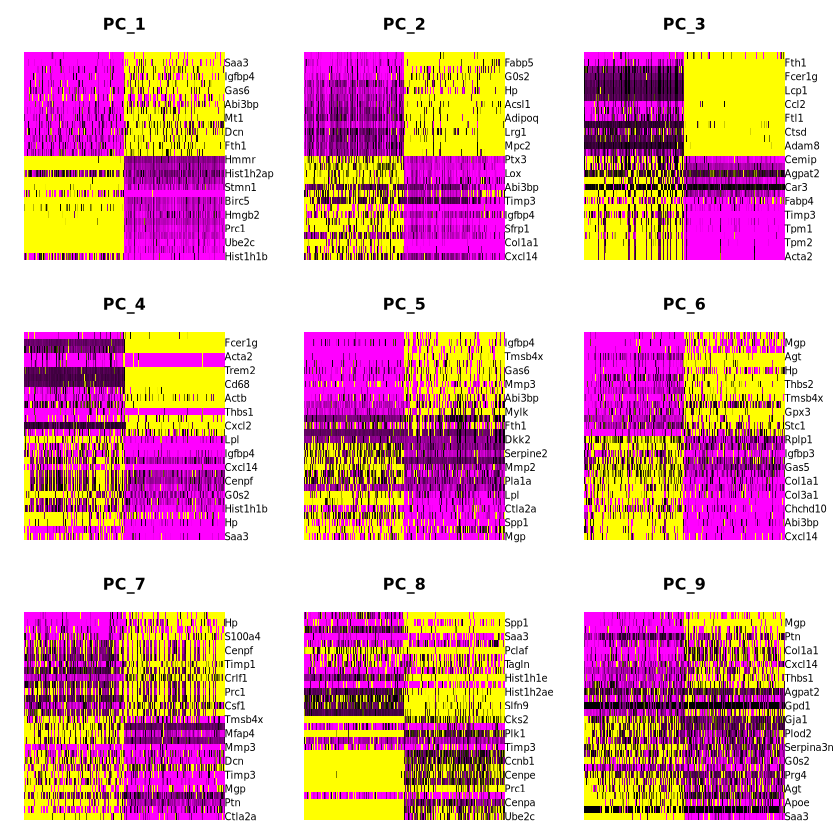

In [25]:
# dimensions 1 to 9
DimHeatmap(adp_filt, dims = 1:9, cells = 500, balanced = TRUE,ncol=3)

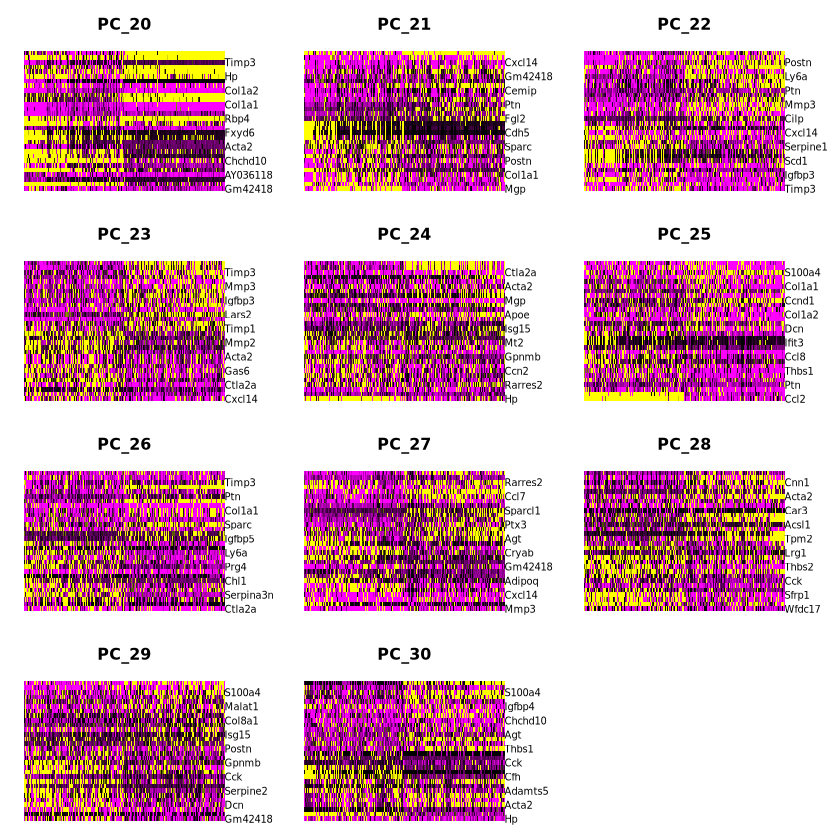

In [26]:
#dimensions 20 to 30
DimHeatmap(adp_filt, dims = 20:30, cells = 500, balanced = TRUE,ncol=3)

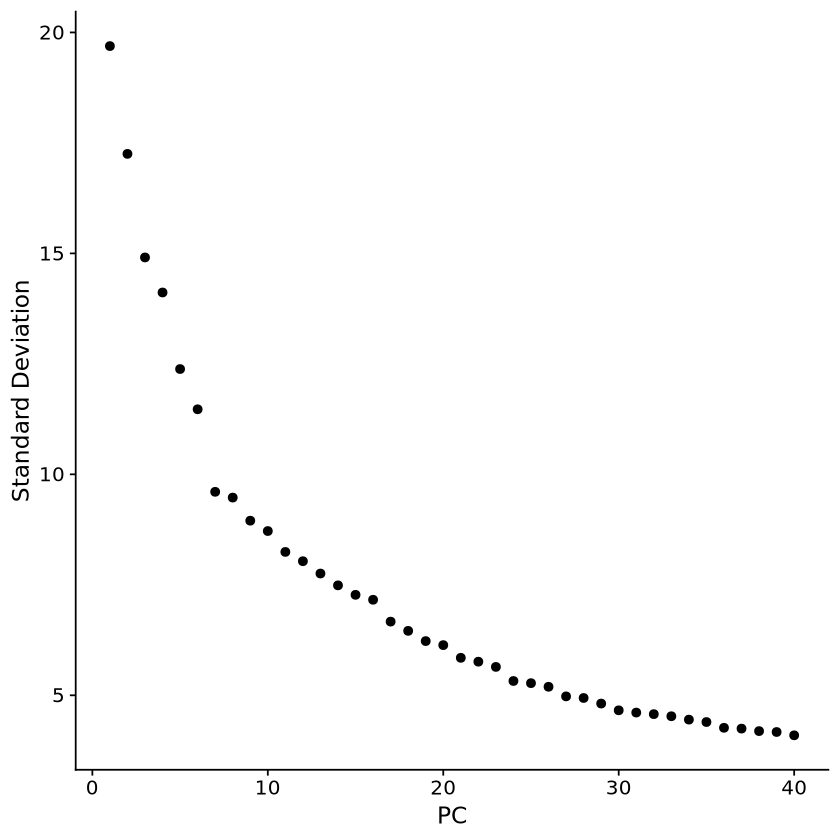

In [27]:
ElbowPlot(adp_filt, ndims = 40)

In [28]:
adp_filt <- FindNeighbors(adp_filt, dims = 1:30)

Computing nearest neighbor graph

Computing SNN



In [29]:
adp_filt <- FindClusters(adp_filt, resolution = 0.1)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 42114
Number of edges: 1477896

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9566
Number of communities: 7
Elapsed time: 8 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (b6dc6f97b6a9ca4b0e80c7fbb4f408fc-791); on b6dc6f97b6a9ca4b0e80c7fbb4f408fc@ip-172-16-85-110.us-west-2.compute.internal<6391>]”


In [30]:
adp_filt <- RunUMAP(adp_filt,dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
09:27:52 UMAP embedding parameters a = 0.9922 b = 1.112

09:27:52 Read 42114 rows and found 30 numeric columns

09:27:52 Using Annoy for neighbor search, n_neighbors = 30

09:27:52 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:27:56 Writing NN index file to temp file /tmp/RtmpOiDnKI/file18f73b4782ce

09:27:56 Searching Annoy index using 22 threads, search_k = 3000

09:27:57 Annoy recall = 100%

09:27:58 Commencing smooth kNN distance calibration using 22 threads
 with target n_neighb

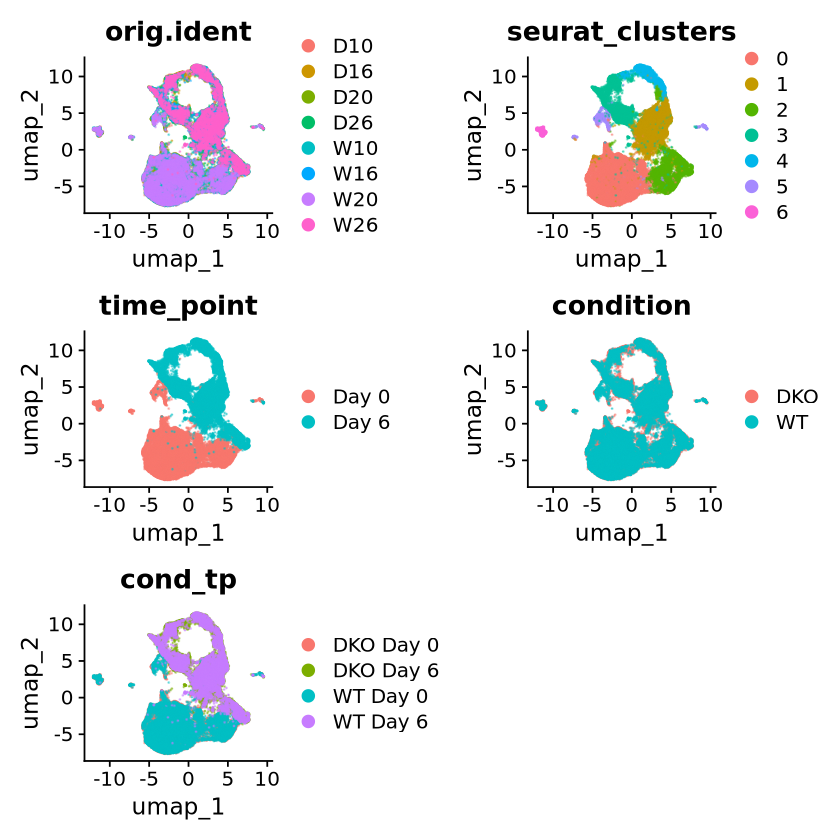

In [31]:
DimPlot(adp_filt, reduction = "umap", group.by = c("orig.ident", "seurat_clusters","time_point","condition","cond_tp"),
        alpha=0.4, ncol=2)

In [32]:
saveRDS(adp_filt, "./adp_merge_filt_sctran_clust0.1.rds")


Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



In [33]:
adp_filt<-PrepSCTFindMarkers(adp_filt,verbose=T)

Found 8 SCT models. Recorrecting SCT counts using minimum median counts: 8146



In [34]:
# find all markers
adp_filt_markers <- FindAllMarkers(adp_filt, only.pos = TRUE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6



In [35]:
#ordering the results
adp_filt_markers <- adp_filt_markers %>% 
  arrange(cluster,desc(avg_log2FC), desc(p_val_adj))

#examine a small subset
adp_filt_markers %>%
    group_by(cluster) %>%
    slice_max(n = 5, order_by = avg_log2FC)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
6.825135e-47,4.259476,0.010,0.001,1.303874e-42,0,Erv3
0.000000e+00,4.098014,0.161,0.011,0.000000e+00,0,Mlana
3.558771e-153,3.997809,0.034,0.002,6.798676e-149,0,Nat8f3
5.482839e-140,3.910931,0.032,0.002,1.047442e-135,0,Pdlim3
0.000000e+00,3.799607,0.109,0.009,0.000000e+00,0,Mamdc2
0.000000e+00,3.510066,0.256,0.043,0.000000e+00,1,Cxcl13
1.510408e-85,3.364613,0.019,0.002,2.885483e-81,1,Hcn4
8.156049e-73,3.346083,0.016,0.002,1.558132e-68,1,Dlx3
0.000000e+00,3.248410,0.383,0.050,0.000000e+00,1,Serpina3m


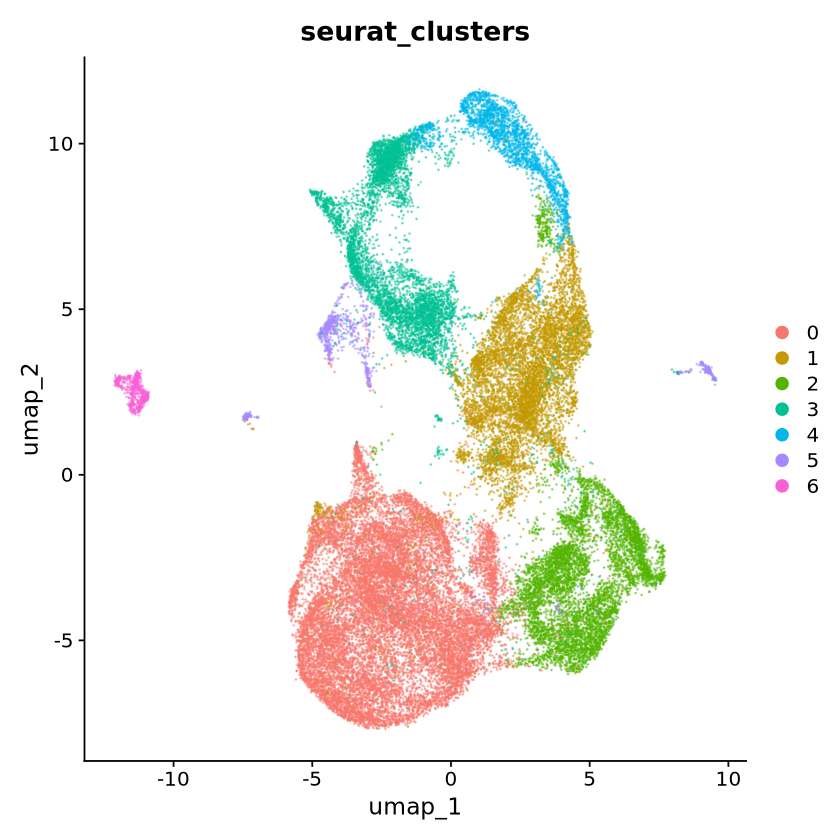

In [36]:
DimPlot(adp_filt, reduction = "umap", group.by = c("seurat_clusters"),
        alpha=0.4)

Warning message in DoHeatmap(adp_filt, features = top20$gene):
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: C1qa, Spi1, Dock2, Ly9, C1qb, Slamf7, Clec4e, Clec4a3, Bcl2a1a, Mgl2, Bcl2a1d, Ly86, Bcl2a1b, Fcrls, Tifab, Slc28a2, Cst7, Gm5150, Myo1g, Gm26740, Dapk2, Mall, Zfp366, Robo4, Gm14207, 9230102K24Rik, Icam2, Gimap4, Gimap1, Kcne3, Gimap5, C1qtnf9, Emcn, Cldn5, Gpihbp1, Nts, Gm32688, Myct1, Sp5, Sox17, Paqr9, Cyp2e1, Sox6os, Ucp1, Apoc3, Gm45607, Ffar4, Thrsp, Acvr1c, Acot5, Acot3, Adora1, A530016L24Rik, D830024N08Rik, Coro6, A830018L16Rik, Amt, Glt1d1, Masp2, Gm17638, Gm43150, 4930565N06Rik, Gm17300, Hist1h3b, Galnt15, Mt3, Cbln2, Smtnl2, Sptssb, Agtr2, Hmgcs2, Gm50114, Pyy, Aox4, Gm45924, Dlx3, Hcn4, Olfml1, Tnfsf8, Tmem178, Gm15866, Sync, Gabrg3, 2810433D01Rik, Akr1c14, Kcnma1, Pdzd7, 8030423F21Rik, Gm12248, Scg2, Kcnq4, Mamdc2, Pdlim3, Nat8f3, Mlana, Erv3”


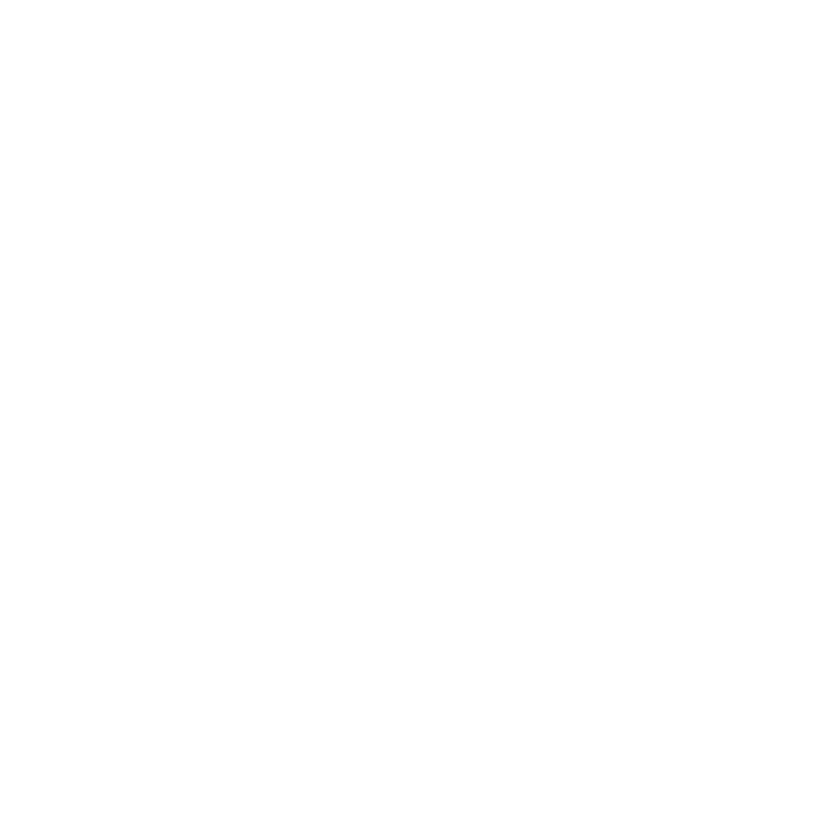

In [37]:
top20<-adp_filt_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 20) %>%
    ungroup() 
DoHeatmap(adp_filt, features = top20$gene) + NoLegend()


In [40]:
# load gene set preparation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
# load cell type annotation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")

In [42]:
seurat_package_v5 <- isFALSE('counts' %in% names(attributes(adp_filt[["RNA"]])));
print(sprintf("Seurat object %s is used", ifelse(seurat_package_v5, "v5", "v4")))

[1] "Seurat object v5 is used"


In [47]:
scRNAseqData_scaled <- if (seurat_package_v5) as.matrix(adp_filt[["SCT"]]$scale.data) else as.matrix(adp_filt[["SCT"]]@scale.data)

In [45]:
adp_filt

An object of class Seurat 
39758 features across 42114 samples within 2 assays 
Active assay: SCT (19104 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

In [52]:
# DB file
db_ <- "https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/ScTypeDB_full.xlsx";
tissue <- "Muscle" # e.g. Immune system,Pancreas,Liver,Eye,Kidney,Brain,Lung,Adrenal,Heart,Intestine,Muscle,Placenta,Spleen,Stomach,Thymus 

# prepare gene sets
gs_list <- gene_sets_prepare(db_, tissue)

Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except

In [53]:
es.max <- sctype_score(scRNAseqData = scRNAseqData_scaled, scaled = TRUE, gs = gs_list$gs_positive, gs2 = gs_list$gs_negative)

In [54]:
cL_resutls <- do.call("rbind", lapply(unique(adp_filt@meta.data$seurat_clusters), function(cl){
    es.max.cl = sort(rowSums(es.max[ ,rownames(adp_filt@meta.data[adp_filt@meta.data$seurat_clusters==cl, ])]), decreasing = !0)
    head(data.frame(cluster = cl, type = names(es.max.cl), scores = es.max.cl, ncells = sum(adp_filt@meta.data$seurat_clusters==cl)), 10)
}))

In [55]:
sctype_scores <- cL_resutls %>% group_by(cluster) %>% top_n(n = 1, wt = scores)  

In [56]:
sctype_scores$type[as.numeric(as.character(sctype_scores$scores)) < sctype_scores$ncells/4] <- "Unknown"
print(sctype_scores[,1:3])

# A tibble: 7 × 3
# Groups:   cluster [7]
  cluster type                        scores
  <fct>   <chr>                        <dbl>
1 0       Unknown                      1035.
2 2       Lymphatic endothelial cells  2584.
3 6       Myeloid cells                4983.
4 3       Unknown                      1226.
5 1       Unknown                      1214.
6 5       Vascular endothelial cells   1109.
7 4       Vascular endothelial cells    643.


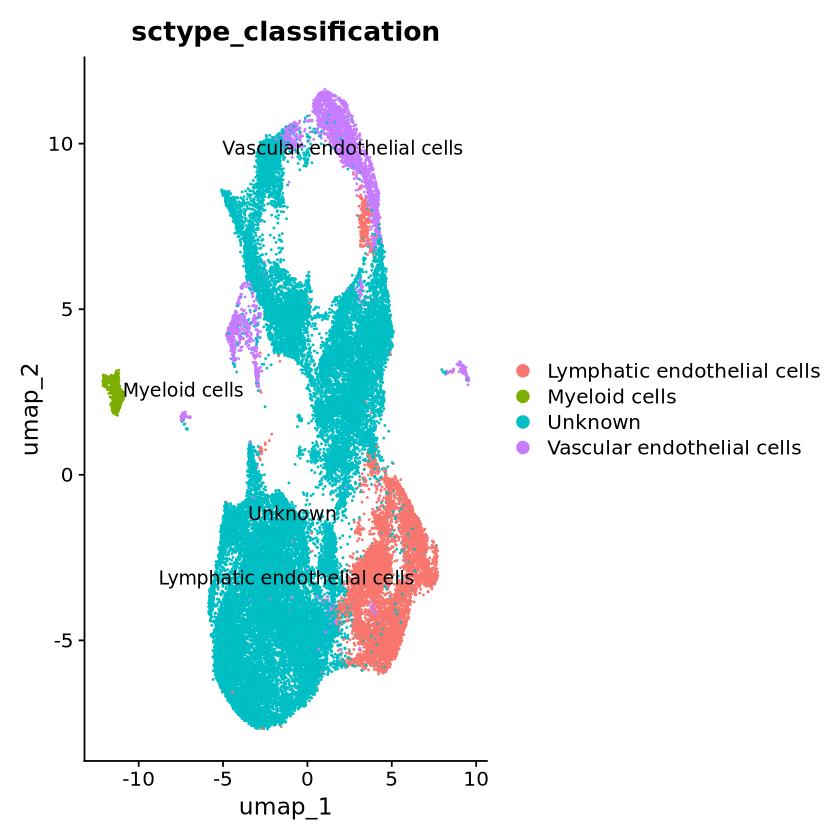

In [57]:
adp_filt@meta.data$sctype_classification = ""
for(j in unique(sctype_scores$cluster)){
  cl_type = sctype_scores[sctype_scores$cluster==j,]; 
  adp_filt@meta.data$sctype_classification[adp_filt@meta.data$seurat_clusters == j] = as.character(cl_type$type[1])
}

DimPlot(adp_filt, reduction = "umap", label = TRUE, repel = TRUE, group.by = 'sctype_classification') 